# M4 — Feature Engineering & a Predictive Response Model

We now build the model most marketing teams actually use: **"who is likely to respond?"**
— a response-propensity model that predicts `P(visit | customer attributes)` among
emailed customers.

We build it for two reasons:
1. To demonstrate **feature engineering**, **predictive modelling**, and **honest model
   evaluation**.
2. To create the **baseline the causal work (M5-M6) must beat**. The central argument of
   this project is that ranking customers by *predicted response* is the **wrong** way to
   target — because some high-response customers would visit anyway. This notebook builds
   that baseline; M6 shows why uplift beats it.

For each model we state the **business question**, the **intuition**, and the
**assumptions** before running it.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mdip.config import load_config
from mdip.data.load import load_hillstrom
from mdip import response_model as rm
from mdip.features import engineer_features, feature_columns
from mdip.viz.style import set_style, COLORS

set_style()
cfg = load_config()
df = load_hillstrom(cfg)

## 1. Feature engineering (RFM framing)

We turn raw columns into better model inputs, guided by the classic **RFM** framework:

- **Recency** — `recency` (months since last purchase), plus a `recent_buyer` flag.
- **Monetary** — `history` (prior-year spend), which is right-skewed, so we use
  `log_history = log(1 + history)`.
- **Frequency** — Hillstrom has no purchase-count column, so true frequency is
  unavailable. We use `categories_bought` (mens + womens) as a light proxy and are
  honest that it is only a proxy.

We **drop** `history_segment` (a coarse binning of `history` → redundant) and raw
`history` (kept as `log_history`), to avoid collinearity that would distort the logistic
coefficients.

In [2]:
sample = engineer_features(df.head())[
    ["recency", "recent_buyer", "history", "log_history", "categories_bought"]
]
sample

,recency,recent_buyer,history,log_history,categories_bought
0,10,0,142.44,4.965917,1
1,6,0,329.08,5.799335,2
2,7,0,180.65,5.202082,1
3,9,0,675.83,6.517420,1
4,2,1,45.34,3.836006,1


In [3]:
print("Model features:", feature_columns())

Model features: ['recency', 'log_history', 'categories_bought', 'mens', 'womens', 'newbie', 'recent_buyer', 'zip_code', 'channel']


## 2. Model A — Logistic Regression (the interpretable baseline)

**Business question:** which attributes are associated with visiting, and in which
direction? Answered via **odds ratios**.

**Intuition:** logistic regression fits an S-curve from a weighted sum of features to a
probability in [0, 1]. Exponentiating a coefficient gives an **odds ratio**: "customers
with this attribute have X× the odds of visiting".

**Assumptions:** log-odds roughly linear in the features; independent observations; no
severe multicollinearity (which is why we removed `history_segment`).

## 3. Model B — LightGBM (a stronger learner, *if* it earns its place)

**Business question:** can we predict response more accurately with nonlinearities and
interactions?

**Intuition:** gradient boosting builds many shallow trees, each correcting the last, and
can capture "recent AND multichannel" effects a linear model misses.

**Assumptions:** almost none about the data distribution (tree-based → no scaling or
linearity needed). The trade-off is interpretability, recovered later with **SHAP**. We
only keep it if it actually beats logistic on held-out **PR-AUC**.

In [4]:
res = rm.train_and_evaluate_both(df, seed=cfg.seed)
pd.DataFrame([
    {"model": e.name, "PR-AUC": round(e.pr_auc,4), "ROC-AUC": round(e.roc_auc,4),
     "Brier": round(e.brier,4)}
    for e in [res["eval_logistic"], res["eval_lightgbm"]]
])

,model,PR-AUC,ROC-AUC,Brier
0,Logistic Regression,0.2367,0.6244,0.1357
1,LightGBM,0.2334,0.6201,0.1357


### Why PR-AUC (not accuracy)?

Visitors are only ~17% of emailed customers. A model that predicts "no visit" for
everyone is 83% *accurate* and completely useless. **PR-AUC (average precision)** focuses
on how well we identify the positive (visitor) class, so it is the honest metric under
imbalance. The dashed "no-skill" line on the PR curve below is at the 17% base rate.

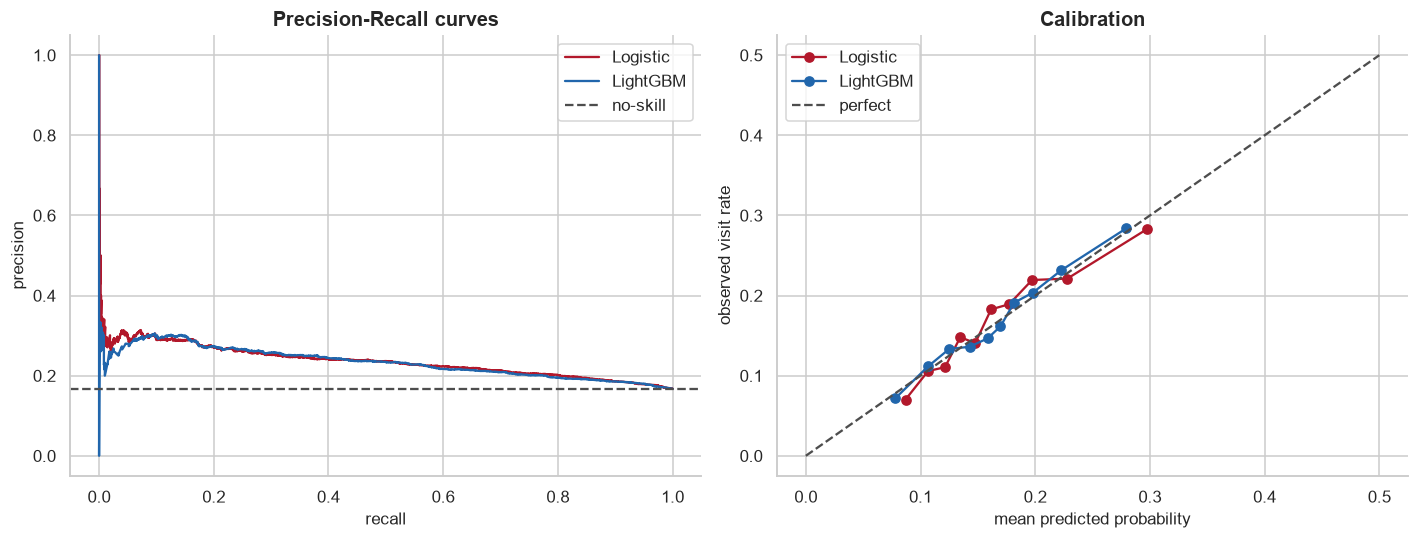

In [5]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for model, name, color in [(res["logistic"],"Logistic",COLORS["control"]),
                           (res["lightgbm"],"LightGBM",COLORS["treated"])]:
    proba = model.predict_proba(res["X_test"])[:,1]
    prec, rec, _ = precision_recall_curve(res["y_test"], proba)
    axes[0].plot(rec, prec, label=name, color=color)
    mp, fp = rm.calibration_points(model, res["X_test"], res["y_test"])
    axes[1].plot(mp, fp, "o-", label=name, color=color)
axes[0].axhline(res["eval_logistic"].positive_rate, ls="--", color=COLORS["neutral"], label="no-skill")
axes[0].set(xlabel="recall", ylabel="precision", title="Precision-Recall curves"); axes[0].legend()
axes[1].plot([0,0.5],[0,0.5], ls="--", color=COLORS["neutral"], label="perfect")
axes[1].set(xlabel="mean predicted probability", ylabel="observed visit rate", title="Calibration"); axes[1].legend()
fig.tight_layout()

**Observation:** logistic PR-AUC ≈ **0.237**, LightGBM ≈ **0.233** — essentially tied,
with logistic marginally ahead. Both sit well above the 0.17 no-skill line and both are
reasonably well **calibrated** (points near the diagonal).

**Conclusion (a deliberately honest one):** with these weak-signal features, the extra
complexity of a gradient-boosted model buys **nothing** — a well-regularised LightGBM only
matches the interpretable logistic model. So I **keep logistic regression** as the
response model. "I tried the fancier model, checked on held-out data, and it didn't beat
the simple one, so I kept the simple one" is exactly the judgement a business wants.

> This is also a signal about the *problem*, not just the models: whether a customer
> visits is only weakly predictable from these attributes (ROC-AUC ≈ 0.62). That's fine —
> our real question isn't "who visits?" but "who visits *because of* the email", which
> needs the causal work, not a better classifier.

## 4. What drives predicted response? — odds ratios & SHAP

In [6]:
res["odds_ratios"].round(3).reset_index(drop=True)

,feature,coefficient,odds_ratio
0,categories_bought,0.445,1.561
1,womens,0.328,1.388
2,newbie,-0.449,0.638
3,zip_code_Urban,-0.292,0.747
4,zip_code_Surburban,-0.289,0.749
5,recent_buyer,0.204,1.226
6,channel_Web,0.166,1.180
7,mens,0.117,1.124
8,log_history,0.107,1.113
9,channel_Phone,-0.075,0.927


**Observation (odds ratios):** buying in more categories (`categories_bought`, OR ≈ 1.56)
and being a women's-category buyer raise the odds of a visit; being a `newbie` lowers them
(OR ≈ 0.64). **Conclusion:** engaged, established multi-category customers respond most —
intuitive, and a good sanity check that the model learned something sensible.

Now the same story from the LightGBM side, via **SHAP** (which recovers interpretability
for the tree model):

C:\Hemant Kothari\Personal Projects\causal inference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Hemant Kothari\Personal Projects\causal inference\.venv\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


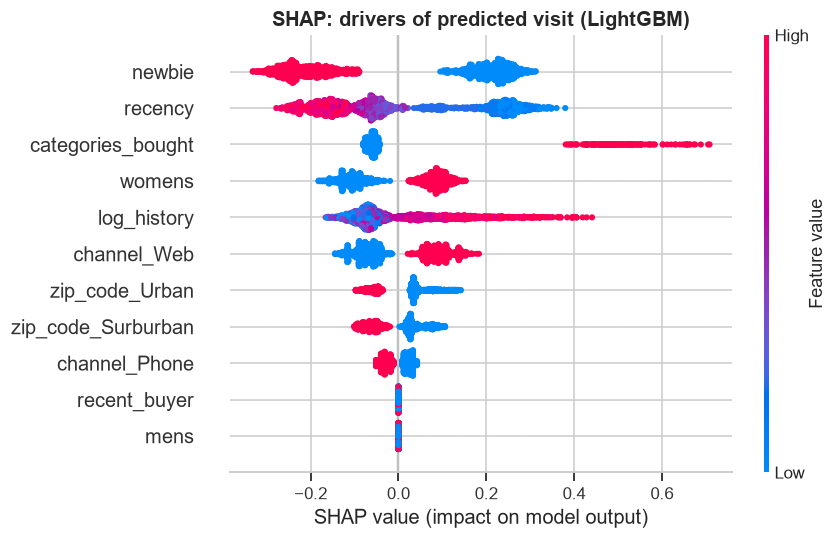

In [7]:
import shap
values, X_sample, names = rm.shap_values_for_lightgbm(res["lightgbm"], res["X_test"])
shap.summary_plot(values, features=X_sample, feature_names=names, show=False, plot_size=(8,5))
plt.title("SHAP: drivers of predicted visit (LightGBM)")
plt.tight_layout()

**Observation:** SHAP agrees with the odds ratios — `categories_bought`, `newbie`, and
`log_history` are the strongest drivers. **Conclusion:** the interpretable and the complex
model tell the same story, which is reassuring.

## 5. The pivot: why this model answers the *wrong* targeting question

This response model ranks customers by **P(visit | emailed)**. But targeting the top of
that list is flawed:

- A customer with high predicted response might visit **whether or not** we email them —
  emailing them is wasted budget (a "sure thing").
- A customer with modest predicted response might be one the email genuinely *tips over*
  (a "persuadable") — exactly who we want, but they rank low here.

The response model cannot tell these apart, because it never looks at the **control
group**. To target correctly we need each customer's **uplift** —
`P(visit | emailed) − P(visit | not emailed)` — which requires causal methods.

**That is the entire motivation for M5 (causal ATE) and M6 (uplift & targeting).**

| | Response model (this notebook) | Uplift model (M6) |
|---|---|---|
| Predicts | who visits if emailed | who visits *because* emailed |
| Uses control group? | no | yes |
| Targets | sure things + persuadables (mixed) | persuadables only |
| Business value | wastes spend on sure things | maximises incremental visits |